In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries downloaded!")

Libraries downloaded!


In [3]:
np.random.seed(42) 
data = np.random.normal(0, 1, 10000)

mean_val = np.mean(data)
std_val = np.std(data)
min_val = np.min(data)
max_val = np.max(data)

print(f"Average: {mean_val:.4f}")
print(f"Standard deviation: {std_val:.4f}")
print(f"Minimum: {min_val:.4f}")
print(f"Maximum: {max_val:.4f}")

Average: -0.0021
Standard deviation: 1.0034
Minimum: -3.9224
Maximum: 3.9262


In [3]:
outliers = data[np.abs(data - mean_val) > 2 * std_val]

count_outliers = len(outliers)
percentage = (count_outliers / len(data)) * 100

print(f"Number of outliers: {count_outliers}")
print(f"Percentage: {percentage:.2f}%")
print(f"Theoretical value: ≈4.55%")

Number of outliers: 462
Percentage: 4.62%
Theoretical value: ≈4.55%


In [4]:
# Task 2
sales = pd.read_csv('kc_house_data.csv')

rows, cols = sales.shape
print(f"1. Dataset has {rows} rows and {cols} columns.")

price_min = sales['price'].min()
price_max = sales['price'].max()
price_avg = sales['price'].mean()
price_med = sales['price'].median()

print(f"\n2. House Price Statistics:")
print(f"   - Minimum: ${price_min:,.2f}")
print(f"   - Maximum: ${price_max:,.2f}")
print(f"   - Average: ${price_avg:,.2f}")
print(f"   - Median:  ${price_med:,.2f}")

unique_zips = sales['zipcode'].nunique()
popular_zip = sales['zipcode'].value_counts().idxmax()
top_zip_count = sales['zipcode'].value_counts().max()

print(f"\n3. Zip Code Analysis:")
print(f"   - Unique zip codes: {unique_zips}")
print(f"   - Most frequent zip code: {popular_zip} ({top_zip_count} listings)")

sales.head()

1. Dataset has 21613 rows and 21 columns.

2. House Price Statistics:
   - Minimum: $75,000.00
   - Maximum: $7,700,000.00
   - Average: $540,088.14
   - Median:  $450,000.00

3. Zip Code Analysis:
   - Unique zip codes: 70
   - Most frequent zip code: 98103 (602 listings)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


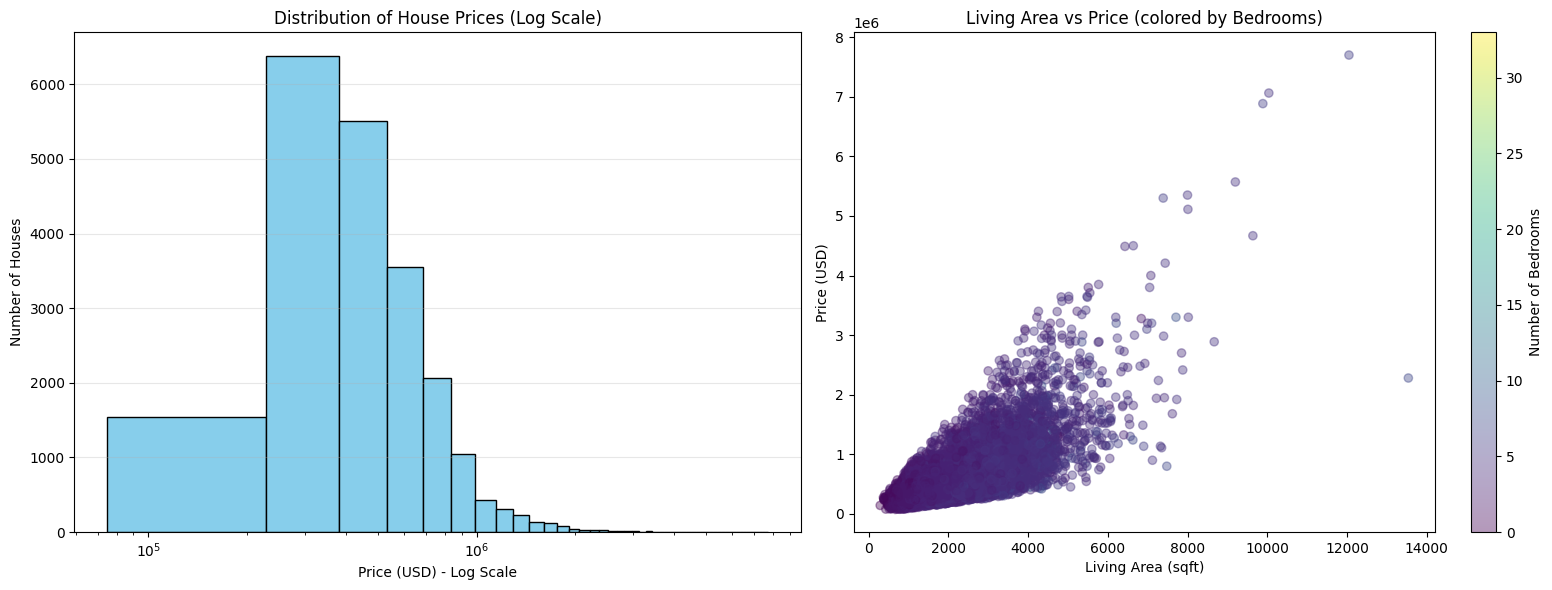

In [5]:
# Task 3

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(sales['price'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xscale('log') 
axes[0].set_title('Distribution of House Prices (Log Scale)')
axes[0].set_xlabel('Price (USD) - Log Scale')
axes[0].set_ylabel('Number of Houses')
axes[0].grid(axis='y', alpha=0.3)

scatter = axes[1].scatter(sales['sqft_living'], sales['price'], 
                           c=sales['bedrooms'], cmap='viridis', alpha=0.4)

axes[1].set_title('Living Area vs Price (colored by Bedrooms)')
axes[1].set_xlabel('Living Area (sqft)')
axes[1].set_ylabel('Price (USD)')

colorbar = fig.colorbar(scatter, ax=axes[1])
colorbar.set_label('Number of Bedrooms')

plt.tight_layout()
plt.show()

In [13]:
# Task 4
X = sales[['sqft_living']]
y = sales['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

intercept = model_1.intercept_
coefficient = model_1.coef_[0]

print(f"1. Model Parameters:")
print(f"   - Intercept: {intercept:,.2f}")
print(f"   - Coefficient (sqft_living): {coefficient:,.2f}")

y_pred = model_1.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\n2. Model Evaluation (Test Set):")
print(f"   - MSE: {mse:,.2f}")
print(f"   - RMSE: ${rmse:,.2f}")

house_size = [[2500]]
predicted_price = model_1.predict(house_size)[0]

print(f"\n3. Prediction Task:")
print(f"   - Predicted price for a 2,500 sq. ft. house: ${predicted_price:,.2f}")


1. Model Parameters:
   - Intercept: -41,999.19
   - Coefficient (sqft_living): 279.55

2. Model Evaluation (Test Set):
   - MSE: 76,484,977,061.78
   - RMSE: $276,559.17

3. Prediction Task:
   - Predicted price for a 2,500 sq. ft. house: $656,887.76


C:\NURE\Magister\second semester\МтАД\lb1\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [14]:
# Task 5

features_2 = ['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']
X2 = sales[features_2]
y = sales['price']

X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model_2 = LinearRegression()
model_2.fit(X2_train, y_train)

y_pred_2 = model_2.predict(X2_test)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))

print(f"Model 1 RMSE (sqft_living only): ${rmse:,.2f}")
print(f"Model 2 RMSE (4 features):      ${rmse_2:,.2f}")

improvement = rmse - rmse_2
print(f"\nImprovement: ${improvement:,.2f} reduction in error.")

Model 1 RMSE (sqft_living only): $276,559.17
Model 2 RMSE (4 features):      $262,985.98

Improvement: $13,573.20 reduction in error.
